
1. Processing Images


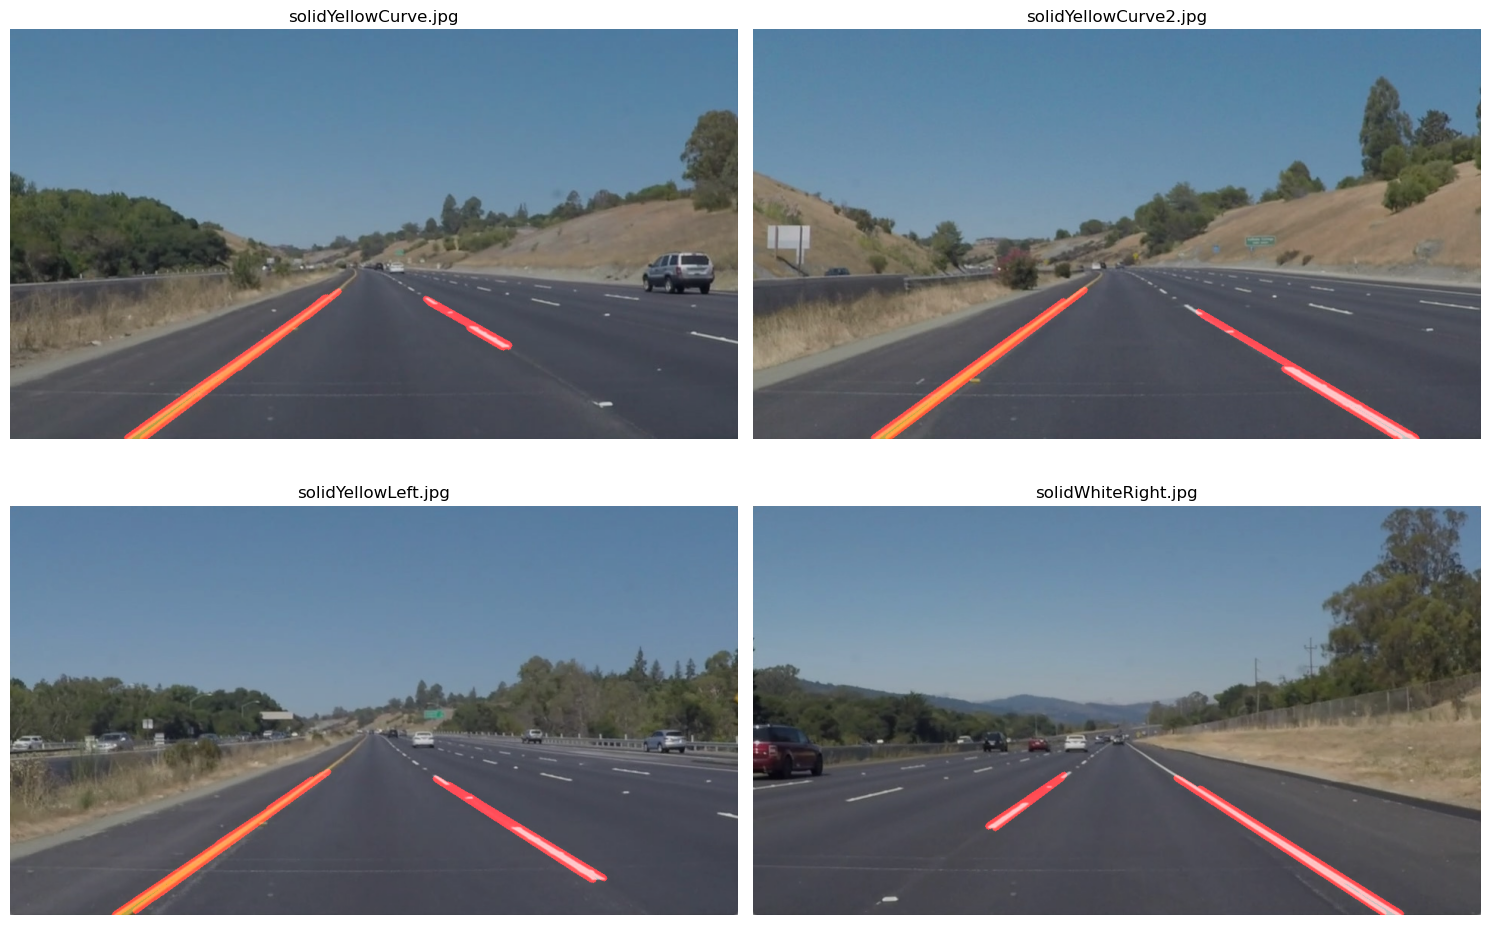


Image processing completed!

2. Processing Video

Video processing completed!
Saved Video: C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\lane_output.mp4

All tasks completed successfully!


In [25]:

# COMPLETE LANE DETECTION PROJECT

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# LINE CLASS
# ============================================================

class Line:

    def __init__(self, x1, y1, x2, y2):

        self.x1 = int(x1)
        self.y1 = int(y1)
        self.x2 = int(x2)
        self.y2 = int(y2)

    def draw(self, img, color=(0, 0, 255), thickness=8):

        cv2.line(
            img,
            (self.x1, self.y1),
            (self.x2, self.y2),
            color,
            thickness
        )

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def grayscale(img):

    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


def gaussian_blur(img, kernel_size=5):

    return cv2.GaussianBlur(
        img,
        (kernel_size, kernel_size),
        0
    )


def canny(img, low_threshold=50, high_threshold=150):

    return cv2.Canny(
        img,
        low_threshold,
        high_threshold
    )


def region_of_interest(img):

    height, width = img.shape

    mask = np.zeros_like(img)

    polygon = np.array([[
        (0, height),
        (width, height),
        (width // 2, int(height * 0.6))
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)

    masked_image = cv2.bitwise_and(img, mask)

    return masked_image


def hough_lines(img):

    lines = cv2.HoughLinesP(
        img,
        rho=2,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=40,
        maxLineGap=100
    )

    return lines


def draw_lines(img, lines):

    if lines is None:
        return img

    line_image = np.zeros_like(img)

    for line in lines:

        for x1, y1, x2, y2 in line:

            lane = Line(x1, y1, x2, y2)

            lane.draw(
                line_image,
                color=(0, 0, 255),
                thickness=8
            )

    output = cv2.addWeighted(
        img,
        0.8,
        line_image,
        1,
        0
    )

    return output

# ============================================================
# LANE DETECTION PIPELINE
# ============================================================

def lane_detection(frame):

    gray = grayscale(frame)

    blur = gaussian_blur(gray)

    edges = canny(blur)

    roi = region_of_interest(edges)

    lines = hough_lines(roi)

    output = draw_lines(frame, lines)

    return output

# ============================================================
# IMAGE PROCESSING
# ============================================================

def process_images():

    base_path = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\test_images"

    image_files = [

        os.path.join(base_path, "solidYellowCurve.jpg"),
        os.path.join(base_path, "solidYellowCurve2.jpg"),
        os.path.join(base_path, "solidYellowLeft.jpg"),
        os.path.join(base_path, "solidWhiteRight.jpg")

    ]

    plt.figure(figsize=(15, 10))

    for i, image_path in enumerate(image_files):

        image = cv2.imread(image_path)

        if image is None:
            print(f"Image not found: {image_path}")
            continue

        image = cv2.resize(image, (960, 540))

        output = lane_detection(image)

        output_rgb = cv2.cvtColor(
            output,
            cv2.COLOR_BGR2RGB
        )

        # Save Output Image
        save_name = "output_" + os.path.basename(image_path)

        cv2.imwrite(save_name, output)

        plt.subplot(2, 2, i + 1)

        plt.imshow(output_rgb)

        plt.title(os.path.basename(image_path))

        plt.axis("off")

    plt.tight_layout()

    plt.show()

    print("\nImage processing completed!")

# ============================================================
# VIDEO PROCESSING
# ============================================================

def process_video():

    input_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\test_videos\solidWhiteRight.mp4"

    output_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\lane_output.mp4"

    cap = cv2.VideoCapture(input_video)

    if not cap.isOpened():

        print("Error opening video file")
        return

    width = 960
    height = 540

    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    out = cv2.VideoWriter(
        output_video,
        fourcc,
        fps,
        (width, height)
    )

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (width, height))

        output = lane_detection(frame)

        out.write(output)

        cv2.imshow("Lane Detection Video", output)

        # Press Q to Quit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()

    out.release()

    cv2.destroyAllWindows()

    print("\nVideo processing completed!")
    print("Saved Video:", output_video)

# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    print("\n==============================")
    print("1. Processing Images")
    print("==============================")

    process_images()

    print("\n==============================")
    print("2. Processing Video")
    print("==============================")

    process_video()

    print("\nAll tasks completed successfully!")

In [13]:
import os
import cv2

# Output video name
output_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\lane_output.mp4"

# Full path of saved video
full_path = os.path.abspath(output_video)

print("\nSaved Video Location:")
print(full_path)

# Open video automatically
cap = cv2.VideoCapture(full_path)

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Lane Output Video", frame)

    # Press Q to exit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Saved Video Location:
C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\lane_output.mp4


In [15]:
# ============================================================
# BASIC PERCEPTION SYSTEM
# ============================================================

import cv2
import numpy as np

# ============================================================
# LOAD PERSON CASCADE
# ============================================================

person_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_fullbody.xml"
)

# ============================================================
# VIDEO PATH
# ============================================================

video_path = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\test_videos\solidWhiteRight.mp4"

cap = cv2.VideoCapture(video_path)

# ============================================================
# CHECK VIDEO
# ============================================================

if not cap.isOpened():

    print("Error Opening Video")
    exit()

# ============================================================
# MAIN LOOP
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Resize
    frame = cv2.resize(frame, (960, 540))

    # Gray Image
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # ========================================================
    # PERSON DETECTION
    # ========================================================

    persons = person_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3
    )

    for (x, y, w, h) in persons:

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        cv2.putText(
            frame,
            "Person",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    # ========================================================
    # SIMPLE VEHICLE DETECTION USING CONTOURS
    # ========================================================

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blur, 50, 150)

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:

        area = cv2.contourArea(contour)

        # Ignore small contours
        if area > 1500:

            x, y, w, h = cv2.boundingRect(contour)

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            cv2.putText(
                frame,
                "Object",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    # ========================================================
    # SHOW OUTPUT
    # ========================================================

    cv2.imshow("Basic Perception", frame)

    cv2.imshow("Edges", edges)

    # Press Q to Exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ============================================================
# RELEASE
# ============================================================

cap.release()

cv2.destroyAllWindows()

print("\nPerception Completed!")


Perception Completed!


In [16]:
# ============================================================
# BASIC PERCEPTION + OUTPUT VIDEO PLAYER
# ============================================================

import cv2
import numpy as np
import os

# ============================================================
# LOAD PERSON CASCADE
# ============================================================

person_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_fullbody.xml"
)

# ============================================================
# INPUT AND OUTPUT VIDEO PATH
# ============================================================

input_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\test_videos\solidWhiteRight.mp4"

output_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\perception.mp4"

# ============================================================
# CREATE VIDEO CAPTURE
# ============================================================

cap = cv2.VideoCapture(input_video)

# ============================================================
# CHECK VIDEO
# ============================================================

if not cap.isOpened():

    print("Error Opening Video")
    exit()

# ============================================================
# VIDEO SETTINGS
# ============================================================

width = 960
height = 540

fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# ============================================================
# SAVE OUTPUT VIDEO
# ============================================================

out = cv2.VideoWriter(
    output_video,
    fourcc,
    fps,
    (width, height)
)

# ============================================================
# MAIN LOOP
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Resize Frame
    frame = cv2.resize(frame, (width, height))

    # ========================================================
    # GRAYSCALE
    # ========================================================

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # ========================================================
    # PERSON DETECTION
    # ========================================================

    persons = person_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3
    )

    for (x, y, w, h) in persons:

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        cv2.putText(
            frame,
            "Person",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    # ========================================================
    # SIMPLE OBJECT DETECTION
    # ========================================================

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blur, 50, 150)

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:

        area = cv2.contourArea(contour)

        if area > 1500:

            x, y, w, h = cv2.boundingRect(contour)

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            cv2.putText(
                frame,
                "Object",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    # ========================================================
    # SAVE OUTPUT VIDEO
    # ========================================================

    out.write(frame)

    # ========================================================
    # SHOW VIDEO
    # ========================================================

    cv2.imshow("Basic Perception System", frame)

    cv2.imshow("Edges", edges)

    # Press Q to Exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ============================================================
# RELEASE
# ============================================================

cap.release()

out.release()

cv2.destroyAllWindows()

# ============================================================
# OUTPUT LOCATION
# ============================================================

print("\nPerception Completed!")

print("\nSaved Video Location:")
print(output_video)

# ============================================================
# PLAY SAVED OUTPUT VIDEO
# ============================================================

full_path = os.path.abspath(output_video)

play = cv2.VideoCapture(full_path)

while play.isOpened():

    ret, frame = play.read()

    if not ret:
        break

    cv2.imshow("Saved Output Video", frame)

    # Press Q to Exit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

play.release()

cv2.destroyAllWindows()


Perception Completed!

Saved Video Location:
C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\perception.mp4


In [17]:
# ============================================================
# BASIC PERCEPTION + EDGE VIDEO SAVE
# ============================================================

import cv2
import numpy as np
import os

# ============================================================
# LOAD PERSON CASCADE
# ============================================================

person_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_fullbody.xml"
)

# ============================================================
# INPUT VIDEO PATH
# ============================================================

input_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\test_videos\solidWhiteRight.mp4"

# ============================================================
# OUTPUT VIDEO PATHS
# ============================================================

output_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\perception_output.mp4"

edges_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\edges_output.mp4"

# ============================================================
# CREATE VIDEO CAPTURE
# ============================================================

cap = cv2.VideoCapture(input_video)

# ============================================================
# CHECK VIDEO
# ============================================================

if not cap.isOpened():

    print("Error Opening Video")
    exit()

# ============================================================
# VIDEO SETTINGS
# ============================================================

width = 960
height = 540

fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# ============================================================
# OUTPUT VIDEO WRITER
# ============================================================

out = cv2.VideoWriter(
    output_video,
    fourcc,
    fps,
    (width, height)
)

# ============================================================
# EDGE VIDEO WRITER
# ============================================================

edge_out = cv2.VideoWriter(
    edges_video,
    fourcc,
    fps,
    (width, height)
)

# ============================================================
# MAIN LOOP
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # ========================================================
    # RESIZE FRAME
    # ========================================================

    frame = cv2.resize(frame, (width, height))

    # ========================================================
    # GRAYSCALE
    # ========================================================

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # ========================================================
    # PERSON DETECTION
    # ========================================================

    persons = person_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3
    )

    for (x, y, w, h) in persons:

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        cv2.putText(
            frame,
            "Person",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    # ========================================================
    # OBJECT DETECTION
    # ========================================================

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blur, 50, 150)

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:

        area = cv2.contourArea(contour)

        if area > 1500:

            x, y, w, h = cv2.boundingRect(contour)

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            cv2.putText(
                frame,
                "Object",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    # ========================================================
    # CONVERT EDGE IMAGE TO 3 CHANNEL
    # ========================================================

    edges_bgr = cv2.cvtColor(
        edges,
        cv2.COLOR_GRAY2BGR
    )

    # ========================================================
    # SAVE VIDEOS
    # ========================================================

    out.write(frame)

    edge_out.write(edges_bgr)

    # ========================================================
    # SHOW OUTPUTS
    # ========================================================

    cv2.imshow(
        "Perception Output",
        frame
    )

    cv2.imshow(
        "Edges Output",
        edges
    )

    # ========================================================
    # EXIT
    # ========================================================

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ============================================================
# RELEASE
# ============================================================

cap.release()

out.release()

edge_out.release()

cv2.destroyAllWindows()

# ============================================================
# OUTPUT LOCATIONS
# ============================================================

print("\nPerception Completed!")

print("\nSaved Perception Video:")
print(output_video)

print("\nSaved Edge Detection Video:")
print(edges_video)

# ============================================================
# PLAY SAVED PERCEPTION VIDEO
# ============================================================

play1 = cv2.VideoCapture(output_video)

while play1.isOpened():

    ret, frame = play1.read()

    if not ret:
        break

    cv2.imshow(
        "Saved Perception Video",
        frame
    )

    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

play1.release()

cv2.destroyAllWindows()

# ============================================================
# PLAY SAVED EDGE VIDEO
# ============================================================

play2 = cv2.VideoCapture(edges_video)

while play2.isOpened():

    ret, frame = play2.read()

    if not ret:
        break

    cv2.imshow(
        "Saved Edge Video",
        frame
    )

    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

play2.release()

cv2.destroyAllWindows()


Perception Completed!

Saved Perception Video:
C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\perception_output.mp4

Saved Edge Detection Video:
C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\edges_output.mp4


In [18]:
# ============================================================
# CONTROL + TRANSMISSION SYSTEM
# SELF DRIVING CAR BASIC CONTROL
# ============================================================

import cv2
import numpy as np
import math

# ============================================================
# VIDEO PATH
# ============================================================

video_path = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\test_videos\solidWhiteRight.mp4"

cap = cv2.VideoCapture(video_path)

# ============================================================
# CHECK VIDEO
# ============================================================

if not cap.isOpened():

    print("Error Opening Video")
    exit()

# ============================================================
# VIDEO SETTINGS
# ============================================================

width = 960
height = 540

# ============================================================
# MAIN LOOP
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # ========================================================
    # RESIZE
    # ========================================================

    frame = cv2.resize(frame, (width, height))

    # ========================================================
    # GRAYSCALE
    # ========================================================

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    # ========================================================
    # BLUR
    # ========================================================

    blur = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # ========================================================
    # EDGE DETECTION
    # ========================================================

    edges = cv2.Canny(
        blur,
        50,
        150
    )

    # ========================================================
    # REGION OF INTEREST
    # ========================================================

    mask = np.zeros_like(edges)

    polygon = np.array([[
        (0, height),
        (width, height),
        (width // 2, int(height * 0.6))
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)

    roi = cv2.bitwise_and(edges, mask)

    # ========================================================
    # HOUGH LINES
    # ========================================================

    lines = cv2.HoughLinesP(
        roi,
        2,
        np.pi / 180,
        50,
        minLineLength=40,
        maxLineGap=100
    )

    # ========================================================
    # STEERING CONTROL
    # ========================================================

    steering_angle = 90

    if lines is not None:

        left_lines = []
        right_lines = []

        for line in lines:

            x1, y1, x2, y2 = line[0]

            slope = (y2 - y1) / (x2 - x1 + 0.001)

            # Left Lane
            if slope < -0.5:
                left_lines.append(line)

            # Right Lane
            elif slope > 0.5:
                right_lines.append(line)

            # Draw lane lines
            cv2.line(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                5
            )

        # ====================================================
        # CONTROL DECISION
        # ====================================================

        if len(left_lines) > len(right_lines):

            steering_angle = 60
            direction = "TURN LEFT"

        elif len(right_lines) > len(left_lines):

            steering_angle = 120
            direction = "TURN RIGHT"

        else:

            steering_angle = 90
            direction = "GO STRAIGHT"

    else:

        direction = "NO LANE"

    # ========================================================
    # SPEED CONTROL
    # ========================================================

    speed = 40

    if direction == "TURN LEFT" or direction == "TURN RIGHT":

        speed = 25

    elif direction == "GO STRAIGHT":

        speed = 40

    # ========================================================
    # TRANSMISSION STATUS
    # ========================================================

    gear = "D"

    # ========================================================
    # DISPLAY CONTROL INFORMATION
    # ========================================================

    cv2.putText(
        frame,
        f"Direction: {direction}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )

    cv2.putText(
        frame,
        f"Steering Angle: {steering_angle}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 0),
        2
    )

    cv2.putText(
        frame,
        f"Speed: {speed} km/h",
        (20, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        frame,
        f"Gear: {gear}",
        (20, 160),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    # ========================================================
    # CENTER GUIDE LINE
    # ========================================================

    cv2.line(
        frame,
        (width // 2, height),
        (width // 2, int(height * 0.6)),
        (255, 0, 255),
        3
    )

    # ========================================================
    # SHOW OUTPUTS
    # ========================================================

    cv2.imshow(
        "Control and Transmission System",
        frame
    )

    cv2.imshow(
        "Lane Edges",
        roi
    )

    # ========================================================
    # EXIT
    # ========================================================

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ============================================================
# RELEASE
# ============================================================

cap.release()

cv2.destroyAllWindows()

print("\nControl and Transmission Completed!")


Control and Transmission Completed!


In [22]:
# ============================================================
# CONTROL + TRANSMISSION SYSTEM
# SELF DRIVING CAR BASIC CONTROL + VIDEO SAVE
# ============================================================

import cv2
import numpy as np
import math
import os

# ============================================================
# VIDEO PATH
# ============================================================

video_path = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\test_videos\solidWhiteRight.mp4"

# ============================================================
# OUTPUT VIDEO PATH
# ============================================================

output_video = r"C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\control_transmission.mp4"

# ============================================================
# CREATE VIDEO CAPTURE
# ============================================================

cap = cv2.VideoCapture(video_path)

# ============================================================
# CHECK VIDEO
# ============================================================

if not cap.isOpened():

    print("Error Opening Video")
    exit()

# ============================================================
# VIDEO SETTINGS
# ============================================================

width = 960
height = 540

fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# ============================================================
# VIDEO WRITER
# ============================================================

out = cv2.VideoWriter(
    output_video,
    fourcc,
    fps,
    (width, height)
)

# ============================================================
# MAIN LOOP
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # ========================================================
    # RESIZE
    # ========================================================

    frame = cv2.resize(frame, (width, height))

    # ========================================================
    # GRAYSCALE
    # ========================================================

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    # ========================================================
    # BLUR
    # ========================================================

    blur = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # ========================================================
    # EDGE DETECTION
    # ========================================================

    edges = cv2.Canny(
        blur,
        50,
        150
    )

    # ========================================================
    # REGION OF INTEREST
    # ========================================================

    mask = np.zeros_like(edges)

    polygon = np.array([[
        (0, height),
        (width, height),
        (width // 2, int(height * 0.6))
    ]], np.int32)

    cv2.fillPoly(mask, polygon, 255)

    roi = cv2.bitwise_and(edges, mask)

    # ========================================================
    # HOUGH LINES
    # ========================================================

    lines = cv2.HoughLinesP(
        roi,
        2,
        np.pi / 180,
        50,
        minLineLength=40,
        maxLineGap=100
    )

    # ========================================================
    # DEFAULT CONTROL VALUES
    # ========================================================

    steering_angle = 90
    direction = "GO STRAIGHT"

    left_lines = []
    right_lines = []

    # ========================================================
    # LANE DETECTION
    # ========================================================

    if lines is not None:

        for line in lines:

            x1, y1, x2, y2 = line[0]

            slope = (y2 - y1) / (x2 - x1 + 0.001)

            # Left Lane
            if slope < -0.5:
                left_lines.append(line)

            # Right Lane
            elif slope > 0.5:
                right_lines.append(line)

            # Draw Lane Lines
            cv2.line(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                5
            )

        # ====================================================
        # CONTROL DECISION
        # ====================================================

        if len(left_lines) > len(right_lines):

            steering_angle = 60
            direction = "TURN LEFT"

        elif len(right_lines) > len(left_lines):

            steering_angle = 120
            direction = "TURN RIGHT"

        else:

            steering_angle = 90
            direction = "GO STRAIGHT"

    else:

        direction = "NO LANE"

    # ========================================================
    # SPEED CONTROL
    # ========================================================

    speed = 40

    if direction == "TURN LEFT" or direction == "TURN RIGHT":

        speed = 25

    elif direction == "NO LANE":

        speed = 0

    # ========================================================
    # TRANSMISSION STATUS
    # ========================================================

    if speed == 0:

        gear = "N"

    elif speed <= 20:

        gear = "1"

    elif speed <= 30:

        gear = "2"

    else:

        gear = "D"

    # ========================================================
    # DISPLAY CONTROL INFORMATION
    # ========================================================

    cv2.putText(
        frame,
        f"Direction: {direction}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 255),
        2
    )

    cv2.putText(
        frame,
        f"Steering Angle: {steering_angle}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 0),
        2
    )

    cv2.putText(
        frame,
        f"Speed: {speed} km/h",
        (20, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        frame,
        f"Gear: {gear}",
        (20, 160),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    # ========================================================
    # CENTER GUIDE LINE
    # ========================================================

    cv2.line(
        frame,
        (width // 2, height),
        (width // 2, int(height * 0.6)),
        (255, 0, 255),
        3
    )

    # ========================================================
    # SAVE OUTPUT VIDEO
    # ========================================================

    out.write(frame)

    # ========================================================
    # SHOW OUTPUTS
    # ========================================================

    cv2.imshow(
        "Control and Transmission System",
        frame
    )

    cv2.imshow(
        "Lane Edges",
        roi
    )

    # ========================================================
    # EXIT
    # ========================================================

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ============================================================
# RELEASE
# ============================================================

cap.release()

out.release()

cv2.destroyAllWindows()

# ============================================================
# OUTPUT LOCATION
# ============================================================

print("\n===================================")
print("CONTROL + TRANSMISSION COMPLETED")
print("===================================")

print("\nSaved Video Location:")
print(output_video)

# ============================================================
# PLAY SAVED VIDEO
# ============================================================

play = cv2.VideoCapture(output_video)

while play.isOpened():

    ret, frame = play.read()

    if not ret:
        break

    cv2.imshow(
        "Saved Control Transmission Video",
        frame
    )

    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

play.release()

cv2.destroyAllWindows()


CONTROL + TRANSMISSION COMPLETED

Saved Video Location:
C:\Users\DELL\OneDrive\Desktop\Ai Self Driving\data\Video\control_transmission.mp4


In [24]:
import cv2

print(cv2.data.haarcascades)

C:\Users\DELL\anaconda3\Lib\site-packages\cv2\data\
